# IWAE on Colored MNIST
Importance-Weighted Autoencoder

In [ ]:
from vae_project.imports import *
from vae_project.dataset import *
from vae_project.utils import *
from vae_project.train.hooks import *
from vae_project.train.losses import iwae_loss
from vae_project import TrainerIWAE, get_dataset, IWAE

In [ ]:
train_ds, val_ds = get_dataset("../data"), get_dataset('../data', train=False)

batch_tfms = [ToBatchTransform(tv.transforms.Pad(2)), Colorize('label')]
collate_fn = CollateWithTransforms(batch_tfms)

In [ ]:
bs = 128
train_dl = DataLoader(train_ds, bs, collate_fn=collate_fn)
val_dl = DataLoader(val_ds, bs*2, collate_fn=collate_fn)
xb, yb = next(iter(train_dl))

In [ ]:
K_train = 5  # importance samples during training
K_eval = 50  # tighter bound for evaluation
seed = 42
latent_dim = 16
h_dim = 64
wd = 1e-4
channels = (3, 32, 64, 128)
epochs = 25
lr = 1e-3

random_seed(seed)
collate_fn = CollateWithTransforms(batch_tfms or [])

dl_kwargs = dict(collate_fn=collate_fn, num_workers=6, persistent_workers=True)
train_dl = DataLoader(train_ds, batch_size=bs, shuffle=True, **dl_kwargs)
val_dl = DataLoader(val_ds, batch_size=bs, **dl_kwargs)

model = IWAE(channels, input_size=(32, 32), latent_dim=latent_dim, h_dim=h_dim)
optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=wd)
hooks = [MetricsHook(), ProgressBarHook()]

trainer_config = dict(
    K_train=K_train,
    K_eval=K_eval,
    model=model,
    train_dl=train_dl,
    valid_dl=val_dl,
    optim=optimizer,
    loss_func=iwae_loss,
    epochs=epochs,
    hooks=hooks,
)

trainer = TrainerIWAE(**trainer_config)

In [ ]:
trainer.fit()

Epoch:   0%|          | 0/25 [00:00<?, ?it/s]

Epoch 1/25 [Train]:   0%|          | 0/469 [00:00<?, ?it/s]

Epoch 1/25 [Valid]:   0%|          | 0/79 [00:00<?, ?it/s]

Epoch 1/25 | Train Loss: 389.8139 | Val Loss: 220.6691


Epoch 2/25 [Train]:   0%|          | 0/469 [00:00<?, ?it/s]

...

Epoch 24/25 [Valid]:   0%|          | 0/79 [00:00<?, ?it/s]

Epoch 24/25 | Train Loss: 171.1210 | Val Loss: 169.2817


Epoch 25/25 [Train]:   0%|          | 0/469 [00:00<?, ?it/s]

Epoch 25/25 [Valid]:   0%|          | 0/79 [00:00<?, ?it/s]

Epoch 25/25 | Train Loss: 170.7579 | Val Loss: 169.3830


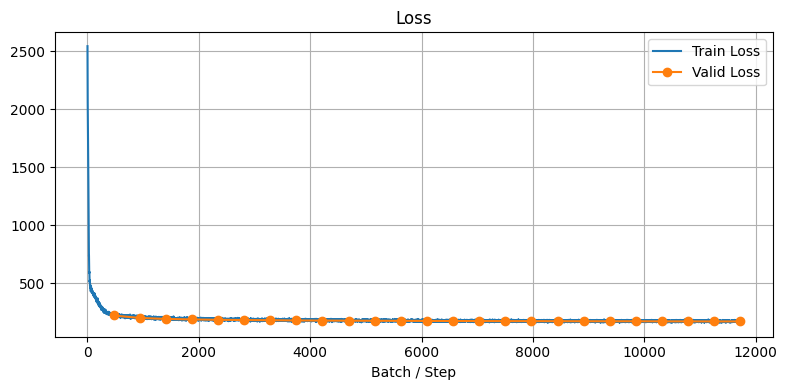

In [ ]:
trainer.get_hook(MetricsHook).plot_loss()

Text(0.5, 1.0, 'Inputs')

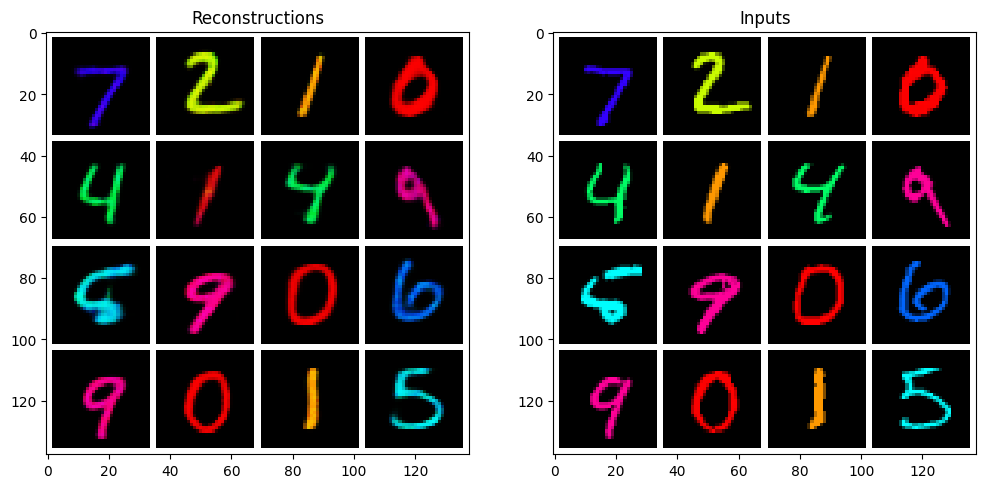

In [ ]:
xb, _ = next(iter(trainer.valid_dl))
x = xb[:16]
recon = trainer.predict(x, training=False)
axes = plt.subplots(ncols=2, figsize=(12,8))[1]
show_imgs(recon[:,0], axes[0])
axes[0].set_title('Reconstructions')
show_imgs(x, axes[1])
axes[1].set_title('Inputs')

### Samples

<Axes: >

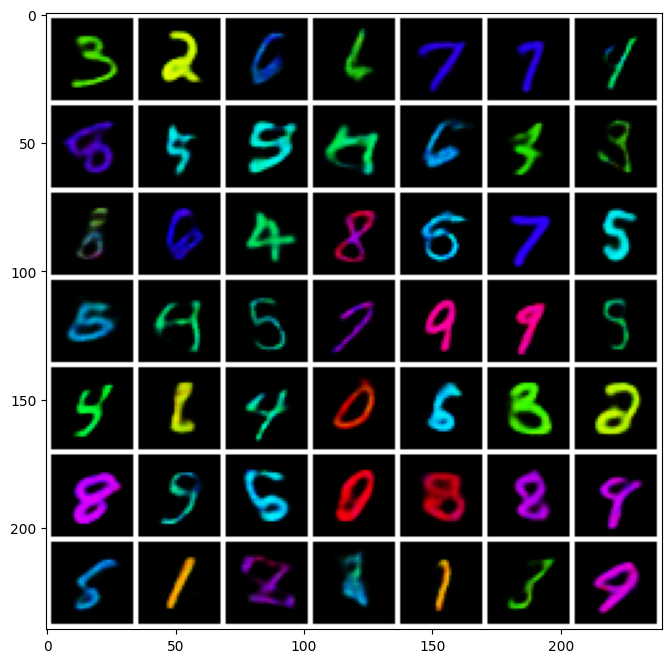

In [ ]:
ax = plt.subplots(figsize=(8,8))[1]
show_imgs(trainer.model.sample(49), ax=ax)